# XGBoost Classification Model for Shipment Delivery Prediction

This notebook explores the use of **XGBoost (Extreme Gradient Boosting)**, a powerful ensemble learning algorithm, to predict whether a shipment will reach on time. 

### Why XGBoost?
- **Performance**: Often outperforms other algorithms in tabular data competitions.
- **Regularization**: Includes L1 and L2 regularization to prevent overfitting.
- **Handling Missing Values**: Automatically learns how to handle missing data.
- **Parallelism**: Designed for efficient, parallelized tree boosting.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

### 1. Data Loading and Initial Exploration
We load the dataset and perform a quick check of its structure and missing values.

In [2]:
df = pd.read_csv("Train.csv")

print("Dataset Shape:", df.shape)
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1



Missing Values:
ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


### 2. Data Preprocessing
XGBoost requires numerical input. We drop the `ID` column as it is a unique identifier with no predictive power, and apply **One-Hot Encoding** to categorical variables.

In [3]:
# Drop ID and split features from target
X = df.drop(["Reached.on.Time_Y.N", "ID"], axis=1)
y = df["Reached.on.Time_Y.N"]

# Handle categorical features
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Processed Features:", X.columns.tolist())

Processed Features: ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'Warehouse_block_B', 'Warehouse_block_C', 'Warehouse_block_D', 'Warehouse_block_F', 'Mode_of_Shipment_Road', 'Mode_of_Shipment_Ship', 'Product_importance_low', 'Product_importance_medium', 'Gender_M']


### 3. Baseline XGBoost Model
We start with a baseline model using initial hyperparameters.

In [4]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print("Baseline Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Baseline Model Accuracy: 0.6759090909090909

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.77      0.66       895
           1       0.80      0.61      0.69      1305

    accuracy                           0.68      2200
   macro avg       0.69      0.69      0.68      2200
weighted avg       0.71      0.68      0.68      2200



### 4. Confusion Matrix Visualization
Visualizing the model's performance on the test set.

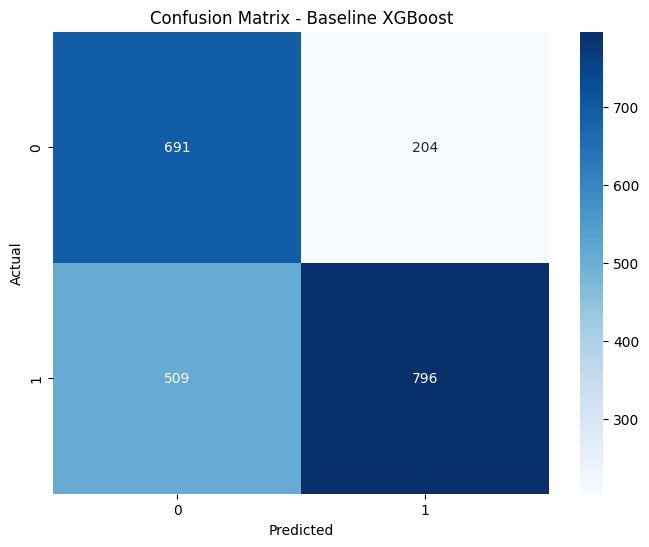

In [5]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Baseline XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 5. Feature Importance
One of the best features of tree-based models is the ability to see which features contributed most to the prediction.

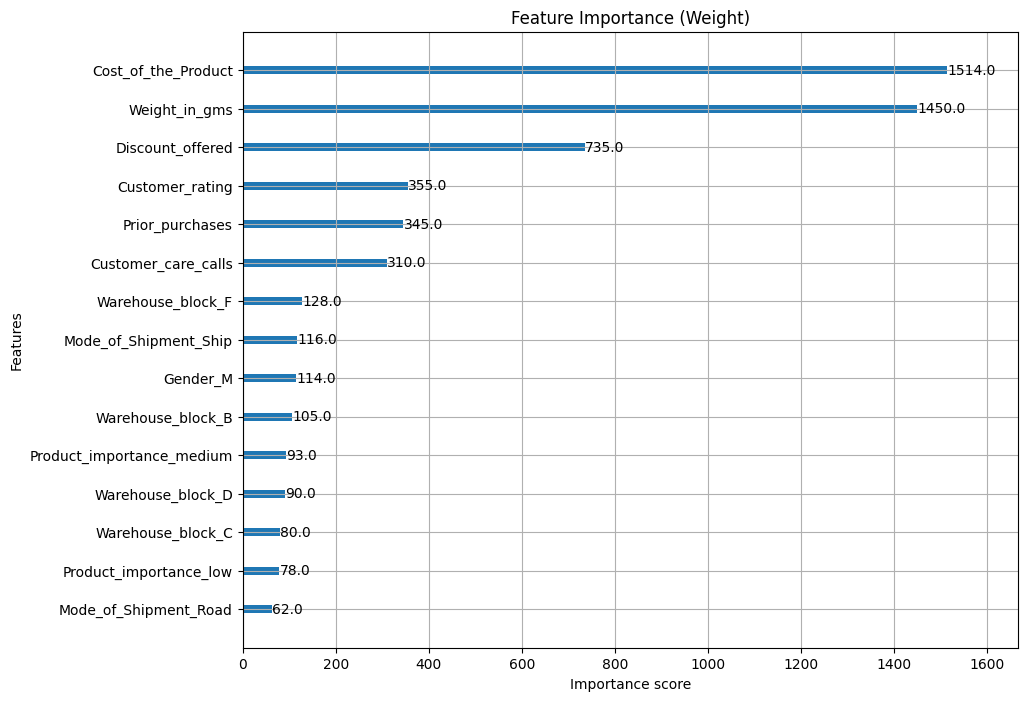

In [6]:
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, ax=plt.gca(), importance_type='weight')
plt.title("Feature Importance (Weight)")
plt.show()

### 6. Hyperparameter Tuning using RandomizedSearchCV
To improve model performance, we search for better hyperparameters.

In [7]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3]
}

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.9}
Best Score: 0.6801909307875894


### 7. Evaluation of Optimized Model
Using the best parameters found by RandomizedSearch.

In [8]:
best_xgb = random_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

print("Optimized Model Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report (Optimized):")
print(classification_report(y_test, y_pred_best))

Optimized Model Accuracy: 0.6895454545454546

Classification Report (Optimized):
              precision    recall  f1-score   support

           0       0.57      0.94      0.71       895
           1       0.93      0.51      0.66      1305

    accuracy                           0.69      2200
   macro avg       0.75      0.73      0.69      2200
weighted avg       0.78      0.69      0.68      2200

